<a href="https://colab.research.google.com/github/chlalswp/MyungKyuYi_ai_class-61354_003-/blob/main/auto_mpg_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Auto MPG 연비 분류: 선형 회귀 · 로지스틱 회귀 · 결정 트리 · KNN

`auto-mpg.data`로 자동차의 **연비가 좋은지(1) 나쁜지(0)** 를 분류하고, 네 가지 모델의 성능을 비교합니다.

- **타깃**: `mpg`(갤런당 마일)가 학습 데이터 중앙값 이상이면 1(연비 좋음), 미만이면 0(연비 나쁨)
- **특성**: cylinders, displacement, horsepower, weight, acceleration, model_year, origin

| 컬럼 | 의미 |
|---|---|
| mpg | 연비 (마일/갤런) |
| cylinders | 실린더 수 |
| displacement | 배기량 (cu. inch) |
| horsepower | 마력 (결측치 `?` 6개) |
| weight | 무게 (lb) |
| acceleration | 0→60mph 가속 시간 (초) |
| model_year | 연식 (70 = 1970년) |
| origin | 제조 지역 (1 미국, 2 유럽, 3 일본) |
| car_name | 차 이름 (분석에서 제외) |

진행 순서: ① 불러오기 → ② 전처리 → ③ 탐색 → ④ 분리·스케일링 → ⑤ 선형 회귀 → ⑥ 로지스틱 회귀 → ⑦ 결정 트리 → ⑧ KNN → ⑨ 모델 비교

## 1. 라이브러리 불러오기

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, RocCurveDisplay, r2_score, mean_squared_error)

RANDOM_STATE = 42

## 2. 데이터 업로드 및 불러오기
셀을 실행하면 파일 선택 버튼이 나옵니다. `auto-mpg.data`를 선택하세요.
이 파일은 **공백으로 구분**되어 있고 헤더가 없으며, 결측치가 `?`로 표시되어 있습니다.

In [ ]:
try:
    from google.colab import files
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
except ImportError:                     \
    file_name = 'auto-mpg.data'

columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
           'acceleration', 'model_year', 'origin', 'car_name']
df = pd.read_csv(file_name, sep=r'\s+', names=columns, na_values='?')

print('데이터 크기:', df.shape)
df.head()

데이터 크기: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


## 3. 전처리

In [ ]:
print('결측치:\n', df.isnull().sum())


df = df.dropna().drop(columns='car_name').reset_index(drop=True)


df['origin'] = df['origin'].map({1: 'usa', 2: 'europe', 3: 'japan'})
df = pd.get_dummies(df, columns=['origin'], dtype=int)

print('\n전처리 후 크기:', df.shape)
df.head()

결측치:
 mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

전처리 후 크기: (392, 10)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504.0,12.0,70,0,0,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,0,0,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,0,0,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,0,0,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,0,0,1


## 4. 데이터 탐색

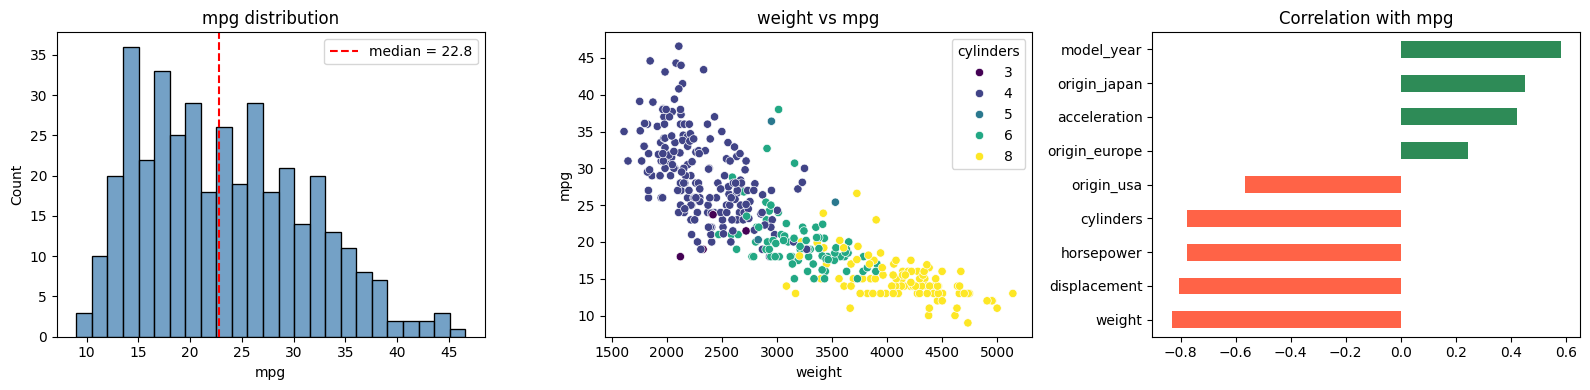

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['mpg'], bins=25, ax=axes[0], color='steelblue')
axes[0].axvline(df['mpg'].median(), color='red', ls='--', label=f"median = {df['mpg'].median():.1f}")
axes[0].set_title('mpg distribution'); axes[0].legend()

sns.scatterplot(data=df, x='weight', y='mpg', hue='cylinders', palette='viridis', ax=axes[1])
axes[1].set_title('weight vs mpg')

corr = df.corr()['mpg'].drop('mpg').sort_values()
corr.plot(kind='barh', ax=axes[2], color=['tomato' if v < 0 else 'seagreen' for v in corr])
axes[2].set_title('Correlation with mpg')
plt.tight_layout(); plt.show()

> 무게·배기량·마력·실린더 수가 클수록 연비가 낮고(음의 상관), 연식이 최신이고 일본·유럽 차일수록 연비가 높습니다(양의 상관).

## 5. 학습/테스트 분리, 타깃 생성, 스케일링
- 8:2로 분리합니다.
- 분류 기준(중앙값)은 **학습 데이터로만** 계산합니다. 테스트 데이터 정보를 쓰면 데이터 누수가 되기 때문입니다.
- 로지스틱 회귀와 KNN은 변수 크기(단위)에 민감하므로 `StandardScaler`로 표준화합니다. 스케일러도 학습 데이터로만 `fit` 합니다.

In [ ]:
feature_cols = [c for c in df.columns if c != 'mpg']
X = df[feature_cols]
mpg = df['mpg']

X_train, X_test, mpg_train, mpg_test = train_test_split(
    X, mpg, test_size=0.2, random_state=RANDOM_STATE,
    stratify=(mpg >= mpg.median()).astype(int))

threshold = mpg_train.median()
y_train = (mpg_train >= threshold).astype(int)
y_test  = (mpg_test  >= threshold).astype(int)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'분류 기준 mpg = {threshold}')
print('학습:', X_train.shape, ' 테스트:', X_test.shape)
print('학습 타깃 비율:', y_train.value_counts().to_dict())

분류 기준 mpg = 23.0
학습: (313, 9)  테스트: (79, 9)
학습 타깃 비율: {1: 157, 0: 156}


In [ ]:

results = {}
def evaluate(name, y_true, y_pred, y_score=None):
    results[name] = {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'ROC-AUC':   roc_auc_score(y_true, y_score) if y_score is not None else np.nan,
    }
    print(f'[{name}]  정확도: {results[name]["Accuracy"]:.4f}\n')
    print(classification_report(y_true, y_pred, target_names=['low mpg (0)', 'high mpg (1)'], digits=3))

## 6. 선형 회귀 (Linear Regression)
선형 회귀는 원래 **연속값을 예측하는 회귀 모델**입니다. 분류에 쓰려면
1. mpg 값을 예측한 다음
2. 예측값이 분류 기준 이상이면 1, 미만이면 0으로 바꿉니다.

회귀 성능(R², RMSE)과 분류 성능을 함께 확인합니다.

회귀 성능  R² = 0.8116,  RMSE = 3.480 mpg

[Linear Regression]  정확도: 0.9114

              precision    recall  f1-score   support

 low mpg (0)      1.000     0.825     0.904        40
high mpg (1)      0.848     1.000     0.918        39

    accuracy                          0.911        79
   macro avg      0.924     0.912     0.911        79
weighted avg      0.925     0.911     0.911        79



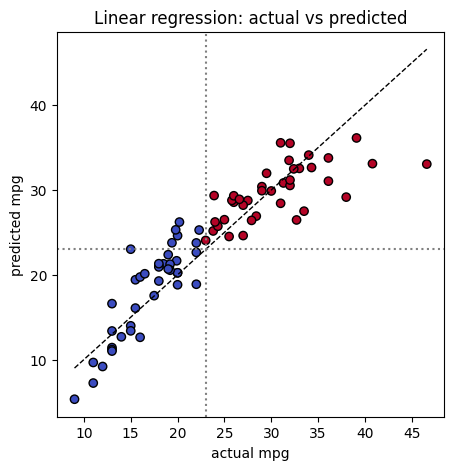

cylinders       -0.593
displacement     0.029
horsepower      -0.030
weight          -0.007
acceleration     0.063
model_year       0.770
origin_europe    1.092
origin_japan     0.770
origin_usa      -1.862


In [ ]:
lin = LinearRegression()
lin.fit(X_train, mpg_train)
mpg_pred = lin.predict(X_test)

print(f'회귀 성능  R² = {r2_score(mpg_test, mpg_pred):.4f},  '
      f'RMSE = {np.sqrt(mean_squared_error(mpg_test, mpg_pred)):.3f} mpg\n')

y_pred_lin = (mpg_pred >= threshold).astype(int)
evaluate('Linear Regression', y_test, y_pred_lin, y_score=mpg_pred)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(mpg_test, mpg_pred, c=y_test, cmap='coolwarm', edgecolor='k')
lims = [mpg.min(), mpg.max()]
ax.plot(lims, lims, 'k--', lw=1)
ax.axhline(threshold, color='gray', ls=':'); ax.axvline(threshold, color='gray', ls=':')
ax.set_xlabel('actual mpg'); ax.set_ylabel('predicted mpg')
ax.set_title('Linear regression: actual vs predicted')
plt.show()

print(pd.Series(lin.coef_, index=feature_cols).round(3).to_string())

> 점선(대각선)에 가까울수록 정확한 예측입니다. 회색 점선(분류 기준)을 기준으로 실제와 예측이 서로 다른 칸에 있는 점이 오분류입니다.

## 7. 로지스틱 회귀 (Logistic Regression)
시그모이드 함수로 **연비가 좋을 확률**을 직접 예측하고, 확률이 0.5 이상이면 1로 분류합니다.
표준화된 데이터를 사용하므로 계수 크기를 서로 비교할 수 있습니다.

[Logistic Regression]  정확도: 0.8987

              precision    recall  f1-score   support

 low mpg (0)      0.944     0.850     0.895        40
high mpg (1)      0.860     0.949     0.902        39

    accuracy                          0.899        79
   macro avg      0.902     0.899     0.899        79
weighted avg      0.903     0.899     0.899        79



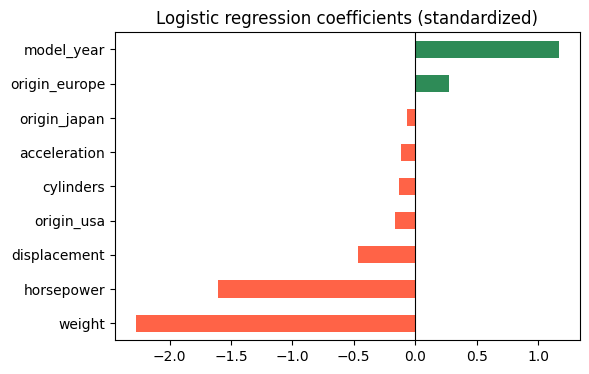

In [ ]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_s, y_train)
y_pred_log = logreg.predict(X_test_s)
evaluate('Logistic Regression', y_test, y_pred_log, y_score=logreg.predict_proba(X_test_s)[:, 1])

coef = pd.Series(logreg.coef_[0], index=feature_cols).sort_values()
coef.plot(kind='barh', figsize=(6, 4), color=['tomato' if v < 0 else 'seagreen' for v in coef])
plt.title('Logistic regression coefficients (standardized)')
plt.axvline(0, color='k', lw=0.8); plt.show()

> 양수(초록) 계수는 값이 클수록 ‘연비 좋음’ 확률을 높이고, 음수(빨강)는 낮춥니다.

## 8. 결정 트리 (Decision Tree)
“weight ≤ 2,800?”처럼 질문을 반복해 데이터를 나누는 모델입니다. 스케일링이 필요 없어 원본 데이터를 그대로 씁니다.
트리가 너무 깊으면 과적합되므로 교차검증으로 `max_depth`를 고릅니다.

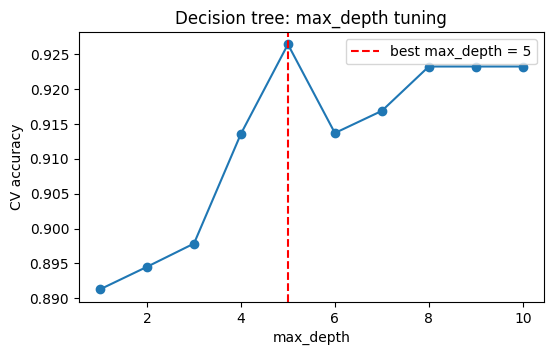

[Decision Tree]  정확도: 0.9114

              precision    recall  f1-score   support

 low mpg (0)      0.971     0.850     0.907        40
high mpg (1)      0.864     0.974     0.916        39

    accuracy                          0.911        79
   macro avg      0.918     0.912     0.911        79
weighted avg      0.918     0.911     0.911        79



In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
depths = range(1, 11)
dt_scores = [cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE),
                             X_train, y_train, cv=cv).mean() for d in depths]
best_depth = depths[int(np.argmax(dt_scores))]

plt.figure(figsize=(6, 3.5))
plt.plot(depths, dt_scores, marker='o')
plt.axvline(best_depth, color='red', ls='--', label=f'best max_depth = {best_depth}')
plt.xlabel('max_depth'); plt.ylabel('CV accuracy'); plt.title('Decision tree: max_depth tuning')
plt.legend(); plt.show()

tree = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
evaluate('Decision Tree', y_test, y_pred_tree, y_score=tree.predict_proba(X_test)[:, 1])

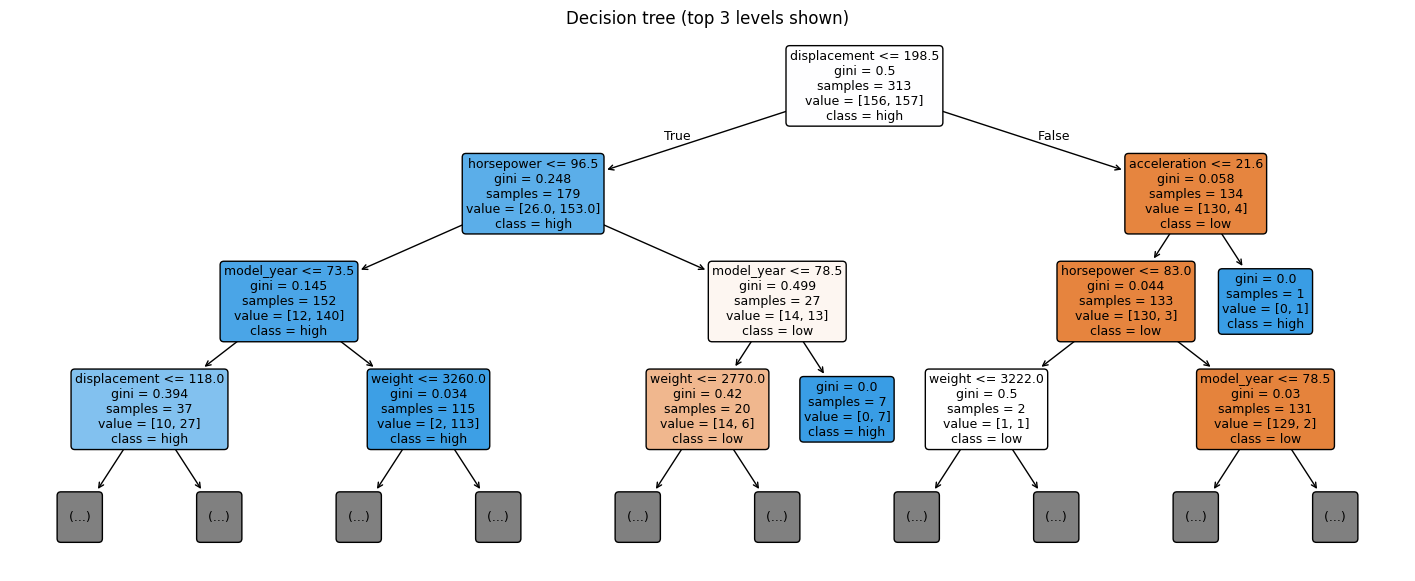

displacement     0.746
model_year       0.076
horsepower       0.069
acceleration     0.052
weight           0.038
cylinders        0.019
origin_europe    0.000
origin_japan     0.000
origin_usa       0.000
dtype: float64

In [ ]:
plt.figure(figsize=(18, 7))
plot_tree(tree, feature_names=feature_cols, class_names=['low', 'high'],
          filled=True, rounded=True, fontsize=9, max_depth=3)
plt.title('Decision tree (top 3 levels shown)')
plt.show()

pd.Series(tree.feature_importances_, index=feature_cols).sort_values(ascending=False).round(3)

## 9. KNN (K-Nearest Neighbors)
새 데이터와 **가장 가까운 K개 이웃**의 다수결로 분류합니다. 거리를 계산하므로 반드시 표준화된 데이터를 써야 합니다.
교차검증으로 가장 좋은 K를 찾습니다 (동점을 피하려고 홀수만 사용).

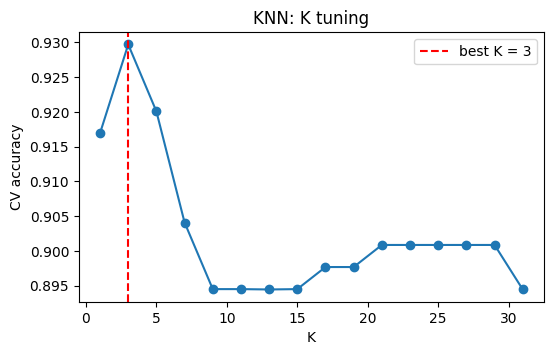

[KNN]  정확도: 0.8987

              precision    recall  f1-score   support

 low mpg (0)      0.944     0.850     0.895        40
high mpg (1)      0.860     0.949     0.902        39

    accuracy                          0.899        79
   macro avg      0.902     0.899     0.899        79
weighted avg      0.903     0.899     0.899        79



In [ ]:
ks = range(1, 32, 2)
knn_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_s, y_train, cv=cv).mean() for k in ks]
best_k = ks[int(np.argmax(knn_scores))]

plt.figure(figsize=(6, 3.5))
plt.plot(ks, knn_scores, marker='o')
plt.axvline(best_k, color='red', ls='--', label=f'best K = {best_k}')
plt.xlabel('K'); plt.ylabel('CV accuracy'); plt.title('KNN: K tuning')
plt.legend(); plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_s, y_train)
y_pred_knn = knn.predict(X_test_s)
evaluate('KNN', y_test, y_pred_knn, y_score=knn.predict_proba(X_test_s)[:, 1])

## 10. 모델 비교

In [ ]:
summary = pd.DataFrame(results).T.round(4)
summary.style.highlight_max(axis=0, color='lightgreen')

,Accuracy,Precision,Recall,F1,ROC-AUC
Linear Regression,0.911400,0.847800,1.000000,0.917600,0.990400
Logistic Regression,0.898700,0.860500,0.948700,0.902400,0.980800
Decision Tree,0.911400,0.863600,0.974400,0.915700,0.938500
KNN,0.898700,0.860500,0.948700,0.902400,0.914100


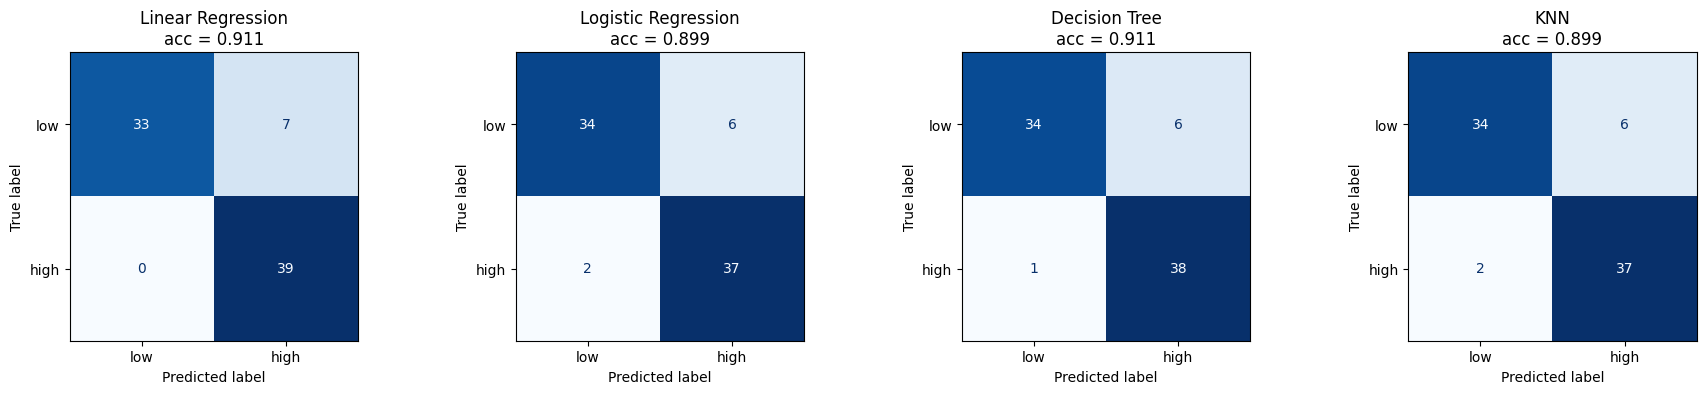

In [ ]:
preds = {'Linear Regression': y_pred_lin, 'Logistic Regression': y_pred_log,
         'Decision Tree': y_pred_tree, 'KNN': y_pred_knn}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, p) in zip(axes, preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, p), display_labels=['low', 'high']) \
        .plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nacc = {accuracy_score(y_test, p):.3f}')
plt.tight_layout(); plt.show()

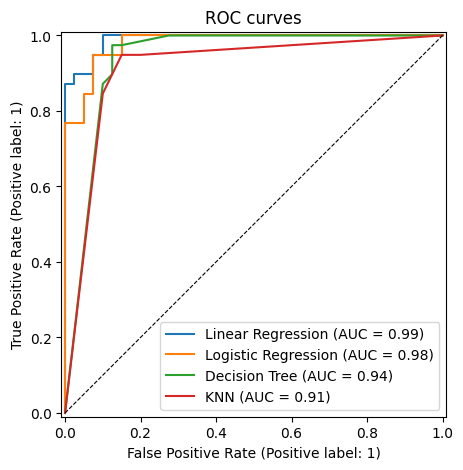

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, mpg_pred, name='Linear Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, logreg.predict_proba(X_test_s)[:, 1], name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, tree.predict_proba(X_test)[:, 1], name='Decision Tree', ax=ax)
RocCurveDisplay.from_predictions(y_test, knn.predict_proba(X_test_s)[:, 1], name='KNN', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_title('ROC curves'); plt.show()

### 정리
| 모델 | 특징 | 스케일링 |
|---|---|---|
| 선형 회귀 | mpg 값을 예측한 뒤 기준값으로 잘라 분류. 회귀 결과(R²)도 함께 얻음 | 불필요 |
| 로지스틱 회귀 | 확률을 직접 예측, 계수로 변수 영향 해석이 쉬움 | 권장 |
| 결정 트리 | 규칙 형태로 결과를 설명하기 쉬움, 깊으면 과적합 | 불필요 |
| KNN | 학습 없이 가까운 이웃으로 분류, K 선택이 중요 | **필수** |

> 테스트 데이터가 79개로 적어서, 모델 간 정확도 차이 1~3%p는 우연일 수도 있습니다. 더 공정하게 비교하려면 교차검증 점수를 함께 보는 것이 좋습니다.

## 11. 새로운 자동차 분류해 보기

In [ ]:
new_cars = pd.DataFrame([

    [4,  97.0,  75, 2155, 16.4, 80, 'japan'],
    [8, 350.0, 165, 4209, 12.0, 72, 'usa'],
    [6, 200.0,  95, 3155, 18.2, 78, 'usa'],
], columns=['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin'])

new_X = pd.get_dummies(new_cars, columns=['origin'], dtype=int).reindex(columns=feature_cols, fill_value=0)
new_X_s = scaler.transform(new_X)

out = new_cars.copy()
out['LinReg mpg 예측'] = lin.predict(new_X).round(1)
out['Linear']   = (lin.predict(new_X) >= threshold).astype(int)
out['Logistic'] = logreg.predict(new_X_s)
out['Tree']     = tree.predict(new_X)
out['KNN']      = knn.predict(new_X_s)
out

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,LinReg mpg 예측,Linear,Logistic,Tree,KNN
0,4,97.0,75,2155,16.4,80,japan,32.7,1,1,1,1
1,8,350.0,165,4209,12.0,72,usa,12.1,0,0,0,0
2,6,200.0,95,3155,18.2,78,usa,23.1,1,0,0,0
